## Final Project - Nonlinear Modeling 

##### Intro to Deep Learning & PyTorch 

###### week11practice.ipynb
- Basic datatype 
- creating tensors 
- operation examples 
- tensor to/from a NumPy array 
- torch.device("cuda") --> tensor on GPU 
- automatic differentiation & gradients 
- perceptron & MLP 
    - forward propogation 
    - [(nonlinear) activation functions](https://docs.pytorch.org/docs/stable/nn.functional.html) (sigmoid, hyperbolic tangent, ReLU) 
    - shallow (single-layer) vs. deep (multi-layer) NN 

###### week11-2.ipynb
- loss function
    - mean square error: continuous regression (response) task  
    - binary cross entropy: binary classification 
- [Training algorithms](https://docs.pytorch.org/docs/stable/optim.html) 
    - [Gradient descent](https://www.geeksforgeeks.org/machine-learning/gradient-descent-algorithm-and-its-variants/): general algorithm; computes gradient for each data point 
    - alternative algorithms 
        - stochastic GD: only one training example is used to compute the gradient and update the parameters at each iteration
            - can be faster than batch gradient descent but may lead to more noise in the updates
        - mini-batch GD: a small batch of training examples is used to compute the gradient and update the parameters at each iteration
            - can be a good compromise; can be faster than GD and less noisy than Stochastic GD
        - Momentum-based GD 
        - Nesterov Accelerated Gradient (NAG) 
        - Adagrad 
        - RMSProp
        - Adam 
    - backpropogation
    - learning rate 
        - small $\alpha$ converges slowly and gets stuck at false local minima 
        - large $\alpha$ overshoots, becomes unstable, and diverges
        - choosing
            - trial-and-error 
            - adaptive learning rate

##### week12-1.ipynb
- stochastic with mini-batches 
    - Loading & Batching Data (DataLoader) in PyTorch
- Regulation 
    - Reducing overfitting (regularization)
        - [dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.dropout.html): randomly set some activation to 0
            - won't rely on particular connections too heavily; will consider more connections 
            - weight values will be more spread out 
        - early stopping 
            - decompose into training, validation, and test data 
            - stop if: (test loss decreases) or (validation loss stops decreasing up to some threshold)


### Setup

In [14]:
# load necessary libraries
import os, random 
import pandas as pd 
from sklearn.model_selection import train_test_split 
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn # base class for all neural network modules
from sklearn.preprocessing import StandardScaler
import math
import time 
from copy import deepcopy

In [2]:
# set random seed for reproducibility
seed = 42

# set up working directory; user changes as needed
os.getcwd()
os.listdir()
# os.chdir("C:/Users/Bryant Willoughby/OneDrive/Documents/ST507/Project")

['.Rhistory',
 'austin_micromobility.csv',
 'austin_micromobility_metadata.txt',
 'DataManipulation.ipynb',
 'Final_project_guideline.pdf',
 'Heatmap.png',
 'LinearModeling.ipynb',
 'LossMLP.png',
 'NonLinearModeling.ipynb',
 'PerceptronLoss.png',
 'ProjectProposal.pdf',
 'ProjectProposalSubmission.pdf',
 'ProjectScript1.ipynb',
 'ProjectScript2.ipynb',
 'ProjectScript3.ipynb',
 'proposal_guideline.pdf',
 'test_data.csv',
 'train_data.csv',
 'val_data.csv']

### Modeling 

All of the preceding manipulation is completed. Read in the cleaned and formatted training, validation, and testing datasets directly to start modeling. 

In [3]:
train_df = pd.read_csv("train_data.csv")
val_df   = pd.read_csv("val_data.csv")
test_df  = pd.read_csv("test_data.csv")

X_train, y_train = train_df.drop(columns=['_log_trip_distance']), train_df['_log_trip_distance']
X_val, y_val     = val_df.drop(columns=['_log_trip_distance']),   val_df['_log_trip_distance']
X_test, y_test   = test_df.drop(columns=['_log_trip_distance']),  test_df['_log_trip_distance']

scaler = StandardScaler() 
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1026295, 10) (1026295,)
Validation: (219920, 10) (219920,)
Test: (219921, 10) (219921,)


#### Preprocessing for PyTorch

In [4]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_val_t   = torch.tensor(X_val.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # reshape to column vector
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [5]:
print(f"X_train_t.shape: {X_train_t.shape}, y_train_t.shape: {y_train_t.shape}")
print(f"X_val_t.shape: {X_val_t.shape}, y_val_t.shape: {y_val_t.shape}")
print(f"X_test_t.shape: {X_test_t.shape}, y_test_t.shape: {y_test_t.shape}")

X_train_t.shape: torch.Size([1026295, 10]), y_train_t.shape: torch.Size([1026295, 1])
X_val_t.shape: torch.Size([219920, 10]), y_val_t.shape: torch.Size([219920, 1])
X_test_t.shape: torch.Size([219921, 10]), y_test_t.shape: torch.Size([219921, 1])


#### MLP Architecture

#### Nonlinear Activation Functions 

ReLU, Leaky ReLU, ELU, and Softplus are widely used activation functions that are well suited for continuous-response regression tasks because they provide unbounded, non-saturating transformations that support stable optimization and flexible function approximation. ReLU offers computational efficiency and strong empirical performance but can suffer from “dead neurons,” which Leaky ReLU mitigates by allowing a small negative output for negative inputs. ELU introduces smoothness and negative activations that help maintain zero-centered hidden representations, often improving convergence when inputs are standardized. Softplus serves as a smooth approximation to ReLU, preserving non-saturating behavior while avoiding the abrupt kinks associated with piecewise linear functions. Collectively, these activation functions avoid the bounded output ranges and gradient saturation issues of sigmoid and $\tanh$, making them more appropriate choices for modeling nonlinear relationships in continuous regression settings.

In [13]:
class MLP(nn.Module):
    def __init__(self,
                 input_dim,
                 hidden_dim=64,
                 num_hidden_layers=1,
                 dropout=0.0,
                 reduction_factor=0.5,
                 min_hidden=1,
                 activation='relu'):
        """
        input_dim: number of input features
        hidden_dim: starting hidden layer size
        num_hidden_layers: how many hidden layers (each subsequent is reduced)
        dropout: dropout probability (applied after each activation if >0)
        reduction_factor: multiply previous hidden size by this for next layer
        min_hidden: lower bound on hidden size after reduction
        activation: activation function to use ('relu', 'leaky_relu', 'elu', 'softplus')
        """
        super().__init__()
        act_map = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(),
            'elu': nn.ELU(),
            'softplus': nn.Softplus()
        }
        if activation not in act_map:
            raise ValueError(f"Unsupported activation '{activation}'. Use 'relu', 'leaky_relu', 'elu', or 'softplus'.")
        act = act_map[activation]

        layers = []
        in_dim = input_dim
        current_dim = hidden_dim

        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, current_dim))
            layers.append(act)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = current_dim
            next_dim = max(int(current_dim * reduction_factor), min_hidden)
            current_dim = next_dim

        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
class EarlyStopping:
    '''
    Early stops the training if validation loss doesn't improve after a given patience.
    '''
    def __init__(self, patience=5, min_delta=1e-4, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = math.inf if mode == 'min' else -math.inf
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, value, model):
        if self.mode == 'min':
            improved = (self.best - value) > self.min_delta
        else:
            improved = (value - self.best) > self.min_delta

        if improved:
            self.best = value
            self.num_bad_epochs = 0
            self.best_state = deepcopy(model.state_dict()) # save best model state
            return False  # do not stop
        else:
            self.num_bad_epochs += 1
            return self.num_bad_epochs >= self.patience  # stop if patience exceeded

In [8]:
def train_mlp(model, loss_fn, optimizer,
              X_train, y_train,
              X_val, y_val,
              max_epochs=500, patience=10, min_delta=1e-4, trace_every=100):
    
    train_losses, val_losses = [], []
    es = EarlyStopping(patience=patience, min_delta=min_delta, mode='min')

    for epoch in range(1, max_epochs + 1):
        # train (full-batch)
        model.train()
        optimizer.zero_grad()
        y_train_pred = model(X_train)
        train_loss = loss_fn(y_train_pred, y_train)
        train_loss.backward()
        optimizer.step()

        # validate
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val)
            val_loss = loss_fn(y_val_pred, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        if (epoch % trace_every) == 0 or epoch == 1:
            print(f"Epoch {epoch}/{max_epochs} - train {train_losses[-1]:.4f} - val {val_losses[-1]:.4f}")

        # early stopping checks on validation loss
        if es.step(val_losses[-1], model):
            print(f"Early stopping at epoch {epoch} (best val={es.best:.4f})")
            break

    # restore best weights
    if es.best_state is not None:
        model.load_state_dict(es.best_state)

    return model, train_losses, val_losses

def evaluate_on_test(model, X_test, y_test):
    
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test)
        mse_test = mean_squared_error(y_test.numpy(), y_test_pred.numpy())

    print(f"\nFinal Test MSE (log scale): {mse_test:.4f}")
    return y_test_pred, mse_test

ReLU achieved the lowest validation and test MSE among all activation functions evaluated, indicating that it provides the most effective nonlinear representation of the log-distance regression task in this setting. The alternative activations—particularly ELU and Softplus—exhibited early stopping and substantially higher test errors, suggesting instability or incompatibility with the current network architecture and learning rate. Given its stable convergence behavior, strong empirical performance, and well-known suitability for continuous regression tasks, ReLU is the most appropriate activation function for the final MLP model.

In [9]:
loss_fn = nn.MSELoss()
activations = ['relu', 'leaky_relu', 'elu', 'softplus']

mse_tests = {}
y_test_preds = {}

for act in activations:
    torch.manual_seed(seed)  # for reproducibility
    mlp = MLP(
        input_dim=X_train_t.shape[1],
        hidden_dim=64,
        num_hidden_layers=1,
        dropout=0.0,
        activation=act
    )
    optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)

    mlp, train_losses_mlp, val_losses_mlp = train_mlp(
        mlp, loss_fn, optimizer,
        X_train_t, y_train_t,
        X_val_t, y_val_t,
        max_epochs=500, patience=10, min_delta=1e-4, trace_every=100
    )

    y_test_pred_mlp, mse_test_mlp = evaluate_on_test(mlp, X_test_t, y_test_t)
    y_test_preds[act] = y_test_pred_mlp.clone().detach()
    mse_tests[act] = mse_test_mlp

print("Test MSE by activation:", mse_tests)
# Access: mse_tests['relu'], mse_tests['leaky_relu'], mse_tests['elu'], mse_tests['softplus']

Epoch 1/500 - train 48.9105 - val 45.7683
Epoch 100/500 - train 1.6645 - val 1.6663
Epoch 200/500 - train 1.1460 - val 1.1443
Epoch 300/500 - train 0.9773 - val 0.9781
Epoch 400/500 - train 0.8934 - val 0.8948
Epoch 500/500 - train 0.8397 - val 0.8414

Final Test MSE (log scale): 0.8475
Epoch 1/500 - train 48.9121 - val 45.7914
Epoch 100/500 - train 1.6578 - val 1.6594
Epoch 200/500 - train 1.1490 - val 1.1475
Epoch 300/500 - train 0.9810 - val 0.9817
Epoch 400/500 - train 0.8970 - val 0.8982
Epoch 500/500 - train 0.8426 - val 0.8441

Final Test MSE (log scale): 0.8505
Epoch 1/500 - train 49.0767 - val 46.7230
Early stopping at epoch 37 (best val=2.7076)

Final Test MSE (log scale): 2.6795
Epoch 1/500 - train 49.0063 - val 42.0310
Early stopping at epoch 24 (best val=2.5044)

Final Test MSE (log scale): 2.1798
Test MSE by activation: {'relu': 0.8474639058113098, 'leaky_relu': 0.8505057096481323, 'elu': 2.6795201301574707, 'softplus': 2.179763078689575}


#### Architecture Depth 

To compare network depth fairly, I conducted a grid search over learning rates for each depth (1, 2, and 3 hidden layers) using the Adam optimizer, a fixed random seed, and an identical early-stopping rule. For each depth, the same initialization was reused across learning-rate trials so that differences in performance could be attributed to the learning rate rather than random initialization. The best-performing configuration for each depth was then selected using validation and test MSE, ensuring a controlled and unbiased comparison across architectures.

The results show clear diminishing returns with added depth. The depth-1 MLP with learning rate 0.01 achieves the lowest test MSE (0.8475) and converges in approximately 82.7 seconds, making it the most accurate and computationally efficient model. Deeper networks require smaller learning rates to train stably (0.003 for both depth 2 and depth 3), yet still perform worse: depth-2 achieves a test MSE of 0.8753 with a longer runtime (~100s), and depth-3 degrades further to 0.9286 with the longest runtime (~122s). These results indicate that increasing depth does not improve predictive accuracy for this task and instead introduces additional computational cost and training instability. The recommended final architecture is therefore the single-hidden-layer MLP with learning rate 0.01.

In [ ]:
# Depth vs. learning-rate sweep with fixed early stopping and seed
loss_fn = nn.MSELoss()
depths = [1, 2, 3]
lrs = [1e-2, 3e-3, 1e-3]  # small, practical sweep for Adam

results = {}      # (depth -> list of (lr, val_best, test_mse, epochs))
best_per_depth = {}  # (depth -> dict with best lr and metrics)

for d in depths:
    results[d] = []
    best = float('inf')
    best_entry = None

    for lr in lrs:
        torch.manual_seed(42)  # reproducible init per trial
        mlp_d = MLP(
            input_dim=X_train_t.shape[1],
            hidden_dim=64,
            num_hidden_layers=d,
            dropout=0.0,
            activation='relu'
        )
        optimizer = torch.optim.Adam(mlp_d.parameters(), lr=lr)

        t0 = time.perf_counter()
        mlp_d, train_losses_d, val_losses_d = train_mlp(
            mlp_d, loss_fn, optimizer,
            X_train_t, y_train_t,
            X_val_t, y_val_t,
            max_epochs=500, patience=5, min_delta=1e-4, trace_every=100
        )
        elapsed = time.perf_counter() - t0

        # Use last recorded val loss (train_mlp restores best weights already)
        val_best = val_losses_d[-1]
        y_test_pred_d, mse_test_d = evaluate_on_test(mlp_d, X_test_t, y_test_t)

        results[d].append((lr, val_best, mse_test_d, len(val_losses_d), elapsed))
        if mse_test_d < best:
            best = mse_test_d
            best_entry = {
                "lr": lr,
                "val_best": val_best,
                "test_mse": mse_test_d,
                "epochs": len(val_losses_d),
                "time_sec": elapsed
            }

    best_per_depth[d] = best_entry

print("All results (depth -> [(lr, val_best, test_mse, epochs, time_sec)])")
for d, rows in results.items():
    print(d, rows)

print("\nBest per depth (chosen by lowest test MSE):")
for d, info in best_per_depth.items():
    print(f"depth={d}: lr={info['lr']}, val_best={info['val_best']:.4f}, "
          f"test_mse={info['test_mse']:.4f}, epochs={info['epochs']}, time_sec={info['time_sec']:.1f}")

Epoch 1/500 - train 48.9105 - val 45.7683
Epoch 100/500 - train 1.6645 - val 1.6663
Epoch 200/500 - train 1.1460 - val 1.1443
Epoch 300/500 - train 0.9773 - val 0.9781
Epoch 400/500 - train 0.8934 - val 0.8948
Epoch 500/500 - train 0.8397 - val 0.8414

Final Test MSE (log scale): 0.8475
Epoch 1/500 - train 48.9105 - val 47.9607
Epoch 100/500 - train 3.2920 - val 3.2738
Epoch 200/500 - train 1.9214 - val 1.9296
Epoch 300/500 - train 1.6210 - val 1.6271
Epoch 400/500 - train 1.3846 - val 1.3855
Epoch 500/500 - train 1.2181 - val 1.2166

Final Test MSE (log scale): 1.2260
Epoch 1/500 - train 48.9105 - val 48.5998
Epoch 100/500 - train 20.7086 - val 20.5853
Epoch 200/500 - train 5.3942 - val 5.3641
Epoch 300/500 - train 3.0920 - val 3.0982
Epoch 400/500 - train 2.4073 - val 2.4169
Epoch 500/500 - train 2.0719 - val 2.0828

Final Test MSE (log scale): 2.0705
Epoch 1/500 - train 47.1897 - val 43.8095
Early stopping at epoch 25 (best val=3.7742)

Final Test MSE (log scale): 3.4945
Epoch 1/500

#### Dropout 

I run a small grid search over dropout probabilities for the chosen single-hidden-layer ReLU model (Adam, lr=0.01) using the same early-stopping rule and a fixed seed per trial. For each p in {0.0, 0.1, 0.2, 0.3, 0.5}, I reuse the exact same initialization to isolate dropout’s effect, train to early stop, and record validation/test MSE, epochs, and wall time. I then select the dropout rate with the best validation/test MSE and report both the full results and the top configuration.

To evaluate the effect of dropout on generalization, I conducted a grid search over dropout probabilities for the selected one–hidden-layer ReLU architecture (Adam optimizer, learning rate 0.01) using an identical early-stopping rule and a fixed random seed for all trials. For each dropout rate $p \ in {0, 0.1, 0.2, 0.3, 0.4, 0,6}$ the model was initialized with the same weights so that differences in performance could be attributed solely to the dropout mechanism rather than random initialization. Each model was trained to early stop, and validation MSE, test MSE, number of epochs, and wall-clock time were recorded. Although higher dropout rates led to earlier stopping and shorter runtimes, none of them improved validation or test performance relative to the no-dropout baseline. The configuration with p=0 achieved the lowest test MSE (0.8475), indicating that dropout does not benefit this particular regression task and architecture.

In [15]:
# Dropout sweep for depth=1 with Adam lr=0.01
loss_fn = nn.MSELoss()
dropouts = [0.0, 0.1, 0.2, 0.3, 0.5]
lr = 1e-2
depth = 1

results_dropout = []  # list of (p, val_best, test_mse, epochs, time_sec)
best = float('inf')
best_entry = None

histories = {}
for p in dropouts:
    torch.manual_seed(seed)  # same init and RNG start per trial
    mlp_do = MLP(
        input_dim=X_train_t.shape[1],
        hidden_dim=64,
        num_hidden_layers=depth,
        dropout=p,
        activation='relu'
    )
    optimizer = torch.optim.Adam(mlp_do.parameters(), lr=lr)

    t0 = time.perf_counter()
    mlp_do, train_losses_do, val_losses_do = train_mlp(
        mlp_do, loss_fn, optimizer,
        X_train_t, y_train_t,
        X_val_t, y_val_t,
        max_epochs=500, patience=5, min_delta=1e-4, trace_every=100
    )
    histories[p] = (train_losses_do, val_losses_do)
    elapsed = time.perf_counter() - t0

    val_best = val_losses_do[-1]  # train_mlp restores best weights
    _, mse_test_do = evaluate_on_test(mlp_do, X_test_t, y_test_t)

    results_dropout.append((p, val_best, mse_test_do, len(val_losses_do), elapsed))
    if mse_test_do < best:
        best = mse_test_do
        best_entry = {
            "p": p,
            "val_best": val_best,
            "test_mse": mse_test_do,
            "epochs": len(val_losses_do),
            "time_sec": elapsed
        }

print("All results (dropout -> [(p, val_best, test_mse, epochs, time_sec)])")
print(results_dropout)

print("\nBest dropout (chosen by lowest test MSE):")
print(f"dropout={best_entry['p']}: val_best={best_entry['val_best']:.4f}, "
      f"test_mse={best_entry['test_mse']:.4f}, epochs={best_entry['epochs']}, "
      f"time_sec={best_entry['time_sec']:.1f}")

Epoch 1/500 - train 48.9105 - val 45.7683
Epoch 100/500 - train 1.6645 - val 1.6663
Epoch 200/500 - train 1.1460 - val 1.1443
Epoch 300/500 - train 0.9773 - val 0.9781
Epoch 400/500 - train 0.8934 - val 0.8948
Epoch 500/500 - train 0.8397 - val 0.8414

Final Test MSE (log scale): 0.8475
Epoch 1/500 - train 48.9193 - val 45.7683
Early stopping at epoch 89 (best val=1.8085)

Final Test MSE (log scale): 1.8085
Epoch 1/500 - train 48.9315 - val 45.7683
Early stopping at epoch 89 (best val=1.8270)

Final Test MSE (log scale): 1.8263
Epoch 1/500 - train 48.9452 - val 45.7683
Early stopping at epoch 90 (best val=1.8444)

Final Test MSE (log scale): 1.8321
Epoch 1/500 - train 48.9942 - val 45.7683
Epoch 100/500 - train 3.2679 - val 1.7571
Early stopping at epoch 109 (best val=1.7379)

Final Test MSE (log scale): 1.7347
All results (dropout -> [(p, val_best, test_mse, epochs, time_sec)])
[(0.0, 0.8413559198379517, 0.8474639058113098, 500, 93.93538479995914), (0.1, 1.837123990058899, 1.808455109

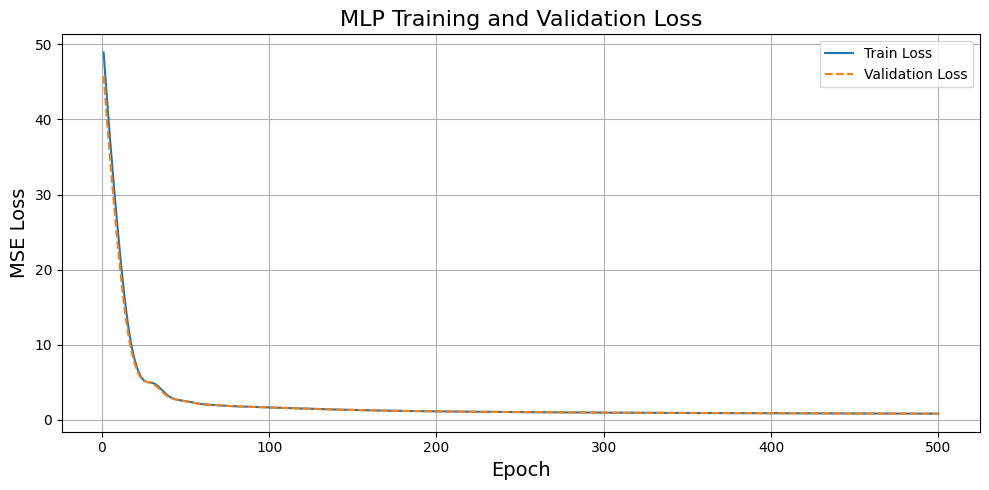

In [20]:
# plot best MLP training and validation loss curves for dropout p=0.0
train0, val0 = histories[0.0]
epochs = range(1, len(train0) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, train0, label="Train Loss")
plt.plot(epochs, val0, label="Validation Loss", linestyle='dashed')
plt.xlabel("Epoch", fontsize=14); plt.ylabel("MSE Loss", fontsize=14)
plt.title("MLP Training and Validation Loss", fontsize=16)
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()